In [1]:
# %matplotlib ipympl
import matplotlib.pyplot as plt
import numpy  as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

torch.set_default_dtype(torch.float32)

In [2]:
# select compute device
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Metal")
else:
    if not torch.backends.mps.is_built():
        print("MPS not available because the current PyTorch install was not "
              "built with MPS enabled.")
    else:
        print("MPS not available because the current MacOS version is not 12.3+ "
              "and/or you do not have an MPS-enabled device on this machine.")

    if torch.cuda.is_available():
        device = torch.device("cuda:0")
        print("Using CUDA")

    else:
        device = torch.device("cpu")
        print("Using CPU")

Using Metal


In [3]:
file = '../data/FeCr/generated_data.csv'

In [4]:
df = pd.read_csv(file)

In [5]:
# # Analysis of dataframe
# df.head()
# df.tail()
# df.shape
# df.info()
# df.keys()
# df.describe()
df.columns
# df.dtypes
# df.isnull() # Booleans indicating missing values
# df.isnull().sum # Number of missing values

Index(['X(CR)', 'G(FCC_A1)', 'G(BCC_A2)', 'G(LIQUID)', 'M(FCC_A1,CR)',
       'M(FCC_A1,FE)', 'M(BCC_A2,CR)', 'M(BCC_A2,FE)', 'M(LIQUID,CR)',
       'M(LIQUID,FE)', 'MU(CR)', 'MU(FE)', 'MUR(CR,FCC_A1)', 'MUR(FE,FCC_A1)',
       'MUR(CR,BCC_A2)', 'MUR(FE,BCC_A2)', 'MUR(CR,LIQUID)', 'MUR(FE,LIQUID)',
       'TEMPERATURE'],
      dtype='object')

In [6]:
inputs = ['X(CR)', 'TEMPERATURE']
outputs = ['G(FCC_A1)', 'G(BCC_A2)', 'G(LIQUID)']

In [7]:
input_df = df[inputs]

In [8]:
# output_df = df.drop(inputs, axis=1)
output_df = df[outputs]

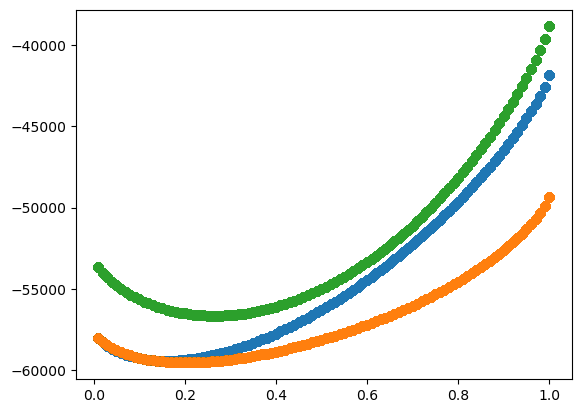

In [10]:
plt.scatter(input_df['X(CR)'], output_df['G(FCC_A1)'])
plt.scatter(input_df['X(CR)'], output_df['G(BCC_A2)'])
plt.scatter(input_df['X(CR)'], output_df['G(LIQUID)'])

In [11]:
# Use 66.6% for training and the rest for testing
train_len = int(len(df) * 0.666)

# Split into train and test sets
choice = np.random.choice(range(len(df)), size=(train_len,), replace=False)

train_idx = np.zeros(len(df), dtype=bool)
train_idx[choice] = True
test_idx = ~train_idx

X_all, Y_all = torch.tensor(np.asarray(input_df), dtype=torch.float32), torch.tensor(np.asarray(output_df), dtype=torch.float32)
X_train, Y_train = X_all[train_idx], Y_all[train_idx]
X_test, Y_test = X_all[test_idx], Y_all[test_idx]

In [12]:
# Data normalization
X_mean = X_all.mean(0, keepdim=True)
X_std = X_all.std(0, keepdim=True)
Y_mean = Y_all.mean(0, keepdim=True)
Y_std = Y_all.std(0, keepdim=True)
# Y_mean = Y_all.mean(0, keepdims=True)
# Y_std = Y_all.std(0, keepdims=True)

def scaled_data(Xu, Yu):
  global X_mean, X_std, Y_mean, Y_std
  X = Xu.detach().clone()
  Y = Yu.detach().clone()
  return((X - X_mean) / X_std, (Y - Y_mean) / Y_std)

# normalized data
X_all_scaled, Y_all_scaled = scaled_data(X_all, Y_all)
X_train_scaled, Y_train_scaled = scaled_data(X_train, Y_train)
X_test_scaled, Y_test_scaled = scaled_data(X_test, Y_test)

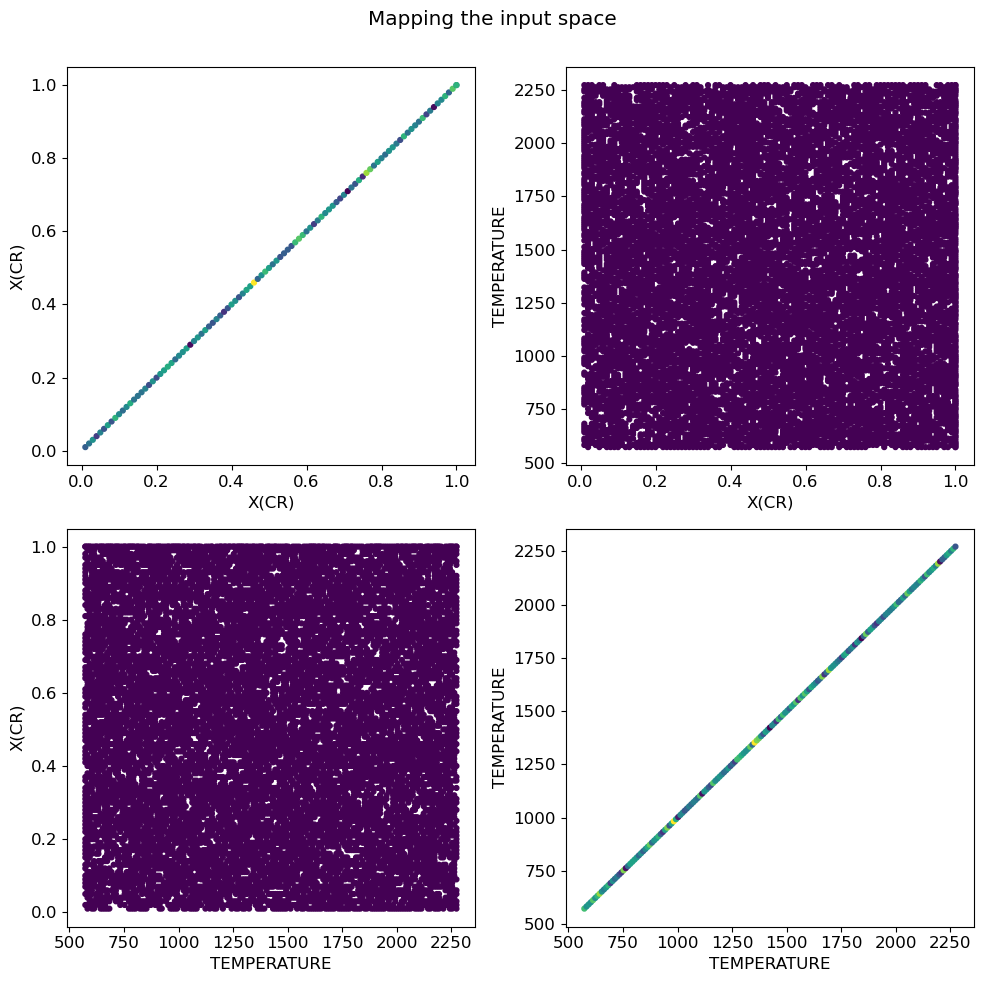

In [13]:
plt.close()
n_cols = len(inputs)
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(nrows=n_cols, ncols=n_cols, figsize = (10, 10))

for i in range(n_cols):
  for j in range(n_cols):
    # only plot unique points for speed
    reduced, counts = np.unique(np.transpose(np.array([X_train[:,i], X_train[:,j]])), axis=0, return_counts=True)
    rx, ry = np.transpose(reduced)

    ax[i][j].scatter(rx, ry, c=counts, s=12)
    ax[i][j].set_xlabel(inputs[i])
    ax[i][j].set_ylabel(inputs[j])
    # ax[i][j].set_xscale('log')
    # ax[i][j].set_yscale('log')

fig.suptitle("Mapping the input space\n")
# plt.savefig('figures/input_space2.pdf')
fig.tight_layout()

plt.show()
# plt.close()

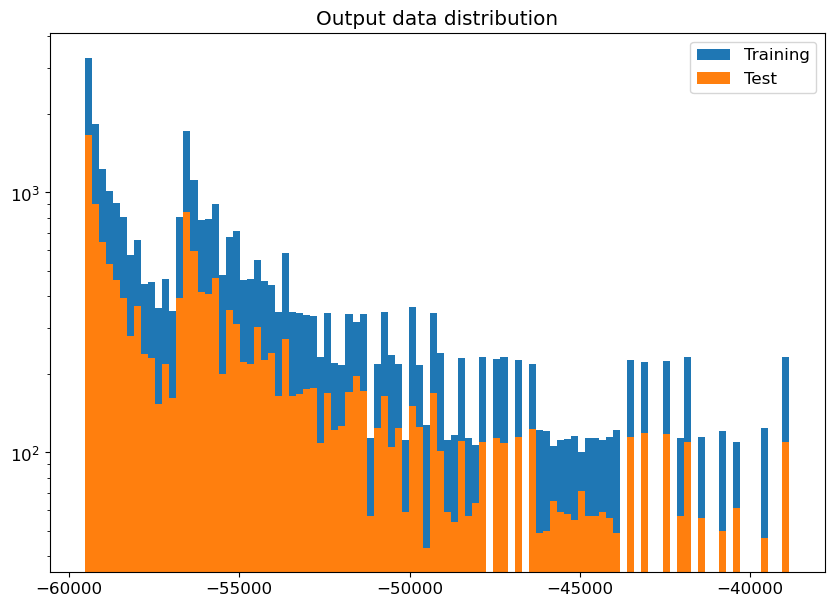

In [14]:
plt.close()
# Creating figure
fig = plt.figure(figsize = (10, 7))
ax = plt.axes()

ax.hist(Y_train[:].flatten().cpu(), bins=100, label="Training")
ax.hist(Y_test[:].flatten().cpu(), bins=100, label="Test")
ax.set_xlabel("")
ax.set_yscale('log')
plt.title("Output data distribution")
plt.legend()

# show plot
plt.show()

In [15]:
losses = []

In [16]:
input_size = X_test_scaled.shape[1]
hidden_size = [12, 12]
output_size = Y_test_scaled.shape[1]

model = nn.Sequential(
    nn.Linear(input_size, hidden_size[0]),
    nn.Sigmoid(),
    nn.Linear(hidden_size[0], hidden_size[1]),
    nn.Sigmoid(),
    nn.Linear(hidden_size[1], output_size))#,

In [17]:
loss_fn = nn.MSELoss()  # binary cross entropy
optimizer = optim.Adam(model.parameters(), lr=0.0001)#, weight_decay=1e-5)#, weight_decay=1e-4

In [18]:
X = X_train_scaled.to(device)
y = Y_train_scaled.float().to(device)
model.to(device)

Sequential(
  (0): Linear(in_features=2, out_features=12, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=12, out_features=12, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=12, out_features=3, bias=True)
)

In [19]:
n_epochs = 10000
batch_size = 100

for epoch in range(n_epochs):
    for i in range(0, len(X), batch_size):
        Xbatch = X[i:i+batch_size]
        y_pred = model(Xbatch)
        ybatch = y[i:i+batch_size]                        # Without softmax normalization
        # ybatch = y_train_normalized[i:i+batch_size]             # With softmax normalization
        loss = loss_fn(y_pred, ybatch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    losses.append(loss.item())
    print(f'Finished epoch {epoch}/{n_epochs} - Loss: {loss}')

Finished epoch 0/10000 - Loss: 7.6792426109313965
Finished epoch 1/10000 - Loss: 7.382035255432129
Finished epoch 2/10000 - Loss: 7.139171600341797
Finished epoch 3/10000 - Loss: 6.936305046081543
Finished epoch 4/10000 - Loss: 6.765161514282227
Finished epoch 5/10000 - Loss: 6.619918346405029
Finished epoch 6/10000 - Loss: 6.496123790740967
Finished epoch 7/10000 - Loss: 6.39021110534668
Finished epoch 8/10000 - Loss: 6.2992262840271
Finished epoch 9/10000 - Loss: 6.220664024353027
Finished epoch 10/10000 - Loss: 6.152355194091797
Finished epoch 11/10000 - Loss: 6.092401027679443
Finished epoch 12/10000 - Loss: 6.039129257202148
Finished epoch 13/10000 - Loss: 5.991065502166748
Finished epoch 14/10000 - Loss: 5.946902751922607
Finished epoch 15/10000 - Loss: 5.905478477478027
Finished epoch 16/10000 - Loss: 5.865752696990967
Finished epoch 17/10000 - Loss: 5.826794624328613
Finished epoch 18/10000 - Loss: 5.787770748138428
Finished epoch 19/10000 - Loss: 5.74794340133667
Finished epoc

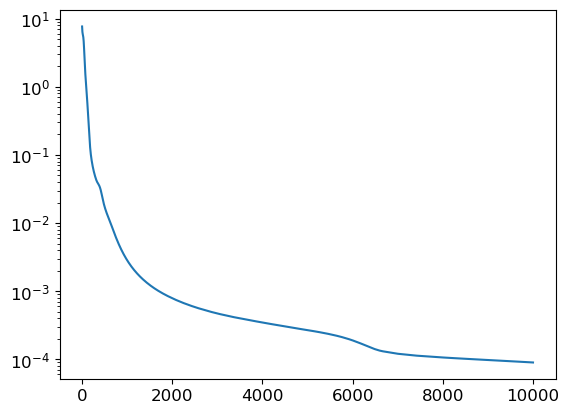

In [20]:
plt.close()
plt.plot()
plt.semilogy(losses)
plt.show()

In [21]:
# compute accuracy for test data set
with torch.no_grad():
    y_pred = model(X_test_scaled.to(device)).cpu() * Y_std + Y_mean

# diff = np.exp(y_pred) - np.exp(Y_test)
# accuracy =diff.mean()
# delta_min = diff.min()
# delta_max = diff.max()
# print(f"Absolute Accuracy {accuracy},  Min {delta_min}, Max {delta_max}")

# diff = (np.exp(y_pred) - np.exp(Y_test))  / np.exp(Y_test)
# accuracy =(diff**2).mean()**.5
# delta_min = (diff**2).min()**.5
# delta_max = (diff**2).max()**.5
# print(f"Relative Accuracy {accuracy},  Min {delta_min}, Max {delta_max}")

In [22]:
(Y_test - y_pred) / y_pred

tensor([[-5.9492e-04, -7.7983e-04, -7.6695e-04],
        [ 1.0991e-04,  2.4277e-05,  3.7466e-05],
        [ 3.1407e-04,  3.0217e-04,  2.9517e-04],
        ...,
        [-5.3638e-04, -3.8708e-04, -7.2352e-04],
        [ 4.8763e-04,  5.5564e-04,  3.7484e-04],
        [-8.5337e-04, -7.2617e-04, -8.4505e-04]])

In [23]:
y_pred

tensor([[-58062.9414, -58040.4609, -53702.9883],
        [-58284.5938, -58247.0859, -54006.8750],
        [-58480.8320, -58431.9453, -54285.0781],
        ...,
        [-44948.6094, -51628.1836, -42543.6797],
        [-43081.7930, -50286.8594, -40288.2969],
        [-41901.9570, -49381.7578, -38884.7578]])

/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_97531/4103050436.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,0]-Y_test[:,0])/Y_test[:,0]), marker='.', alpha=0.2, label='FCC')
/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_97531/4103050436.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,1]-Y_test[:,1])/Y_test[:,1]), marker='.', alpha=0.2, label='BCC')
/var/folders/wc/8ppk7xj10vbc_xtfrp0k7bnnjj2tt8/T/ipykernel_97531/4103050436.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.scatter(X_test[:,0], np.abs((y_pred[:,2]-Y_test[:,2])/Y_test[:,2]), marker='.', alpha=0.2, label='Liquid')


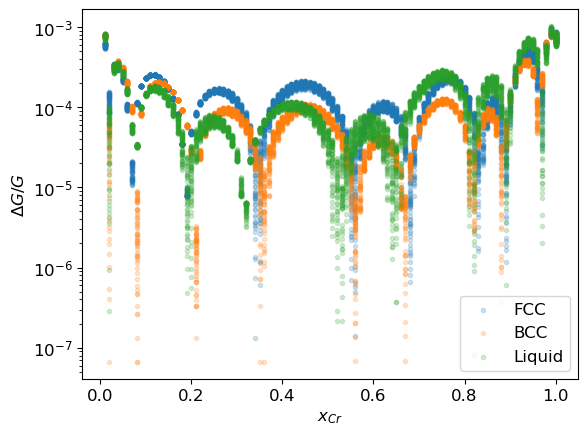

In [24]:
plt.close()
plt.scatter(X_test[:,0], np.abs((y_pred[:,0]-Y_test[:,0])/Y_test[:,0]), marker='.', alpha=0.2, label='FCC')
plt.scatter(X_test[:,0], np.abs((y_pred[:,1]-Y_test[:,1])/Y_test[:,1]), marker='.', alpha=0.2, label='BCC')
plt.scatter(X_test[:,0], np.abs((y_pred[:,2]-Y_test[:,2])/Y_test[:,2]), marker='.', alpha=0.2, label='Liquid')
plt.yscale('log')
plt.ylabel(r'$\Delta G / G$')
plt.xlabel(r'$x_{Cr}$')
plt.legend()
plt.show()

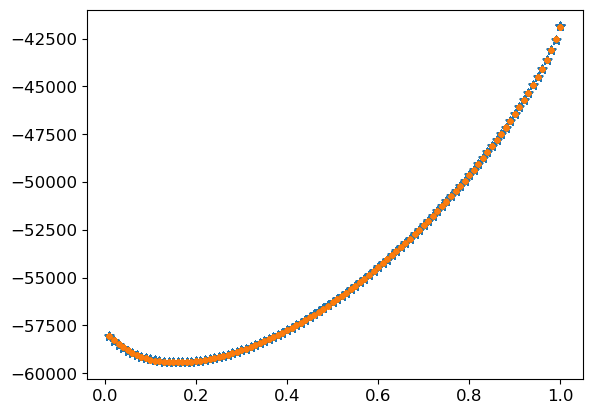

In [25]:
plt.close()

plt.scatter(X_test[:,0], Y_test[:,0], marker='*', alpha=0.25)
plt.scatter(X_test[:,0], y_pred[:,0], marker='.', alpha=0.25)
# plt.yscale('symlog')
plt.show()

In [26]:
with torch.no_grad():
    y_pred1 = model.to(device)(X_train.to(device)).cpu() * Y_std + Y_mean
    y_pred2 = model.to(device)(X_test.to(device)).cpu() * Y_std + Y_mean
    y_pred_all = model.to(device)(X_all.to(device)).cpu() * Y_std + Y_mean

# NN error
y_err1 = ((Y_train) - (y_pred1)) / (Y_train)
y_err2 = ((Y_test) - (y_pred2)) / (Y_test)
y_err_all = ((Y_all) - (y_pred_all)) / (Y_all)

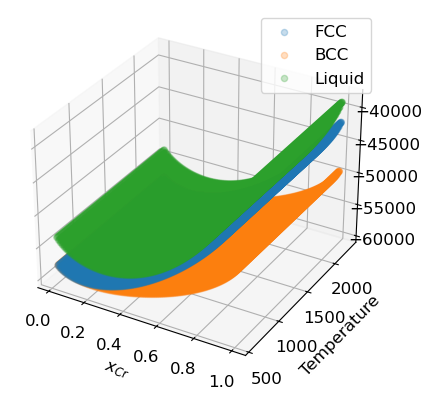

In [27]:
plt.close()
# plt.style.use('_mpl-gallery-nogrid')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,0], label=r'FCC', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,1], label=r'BCC', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], Y_all[:,2], label=r'Liquid', alpha=0.25)
plt.xlabel(r'$x_{Cr}$')
plt.ylabel(r'Temperature')
plt.legend()
# plt.zlabel(r'$G$')
plt.show()


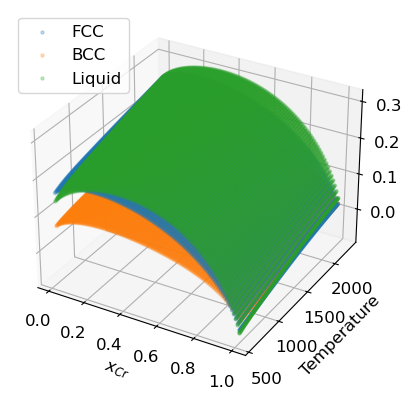

In [28]:
plt.close()
# plt.style.use('_mpl-gallery-nogrid')

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,0], label=r'FCC', marker='.', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,1], label=r'BCC', marker='.', alpha=0.25)
ax.scatter(X_all[:,0], X_all[:,1], y_err_all[:,2], label=r'Liquid', marker='.', alpha=0.25)
plt.xlabel(r'$x_{Cr}$')
plt.ylabel(r'Temperature')
plt.legend()
# plt.zlabel(r'$G$')
plt.show()

IndexError: index 2 is out of bounds for dimension 1 with size 2

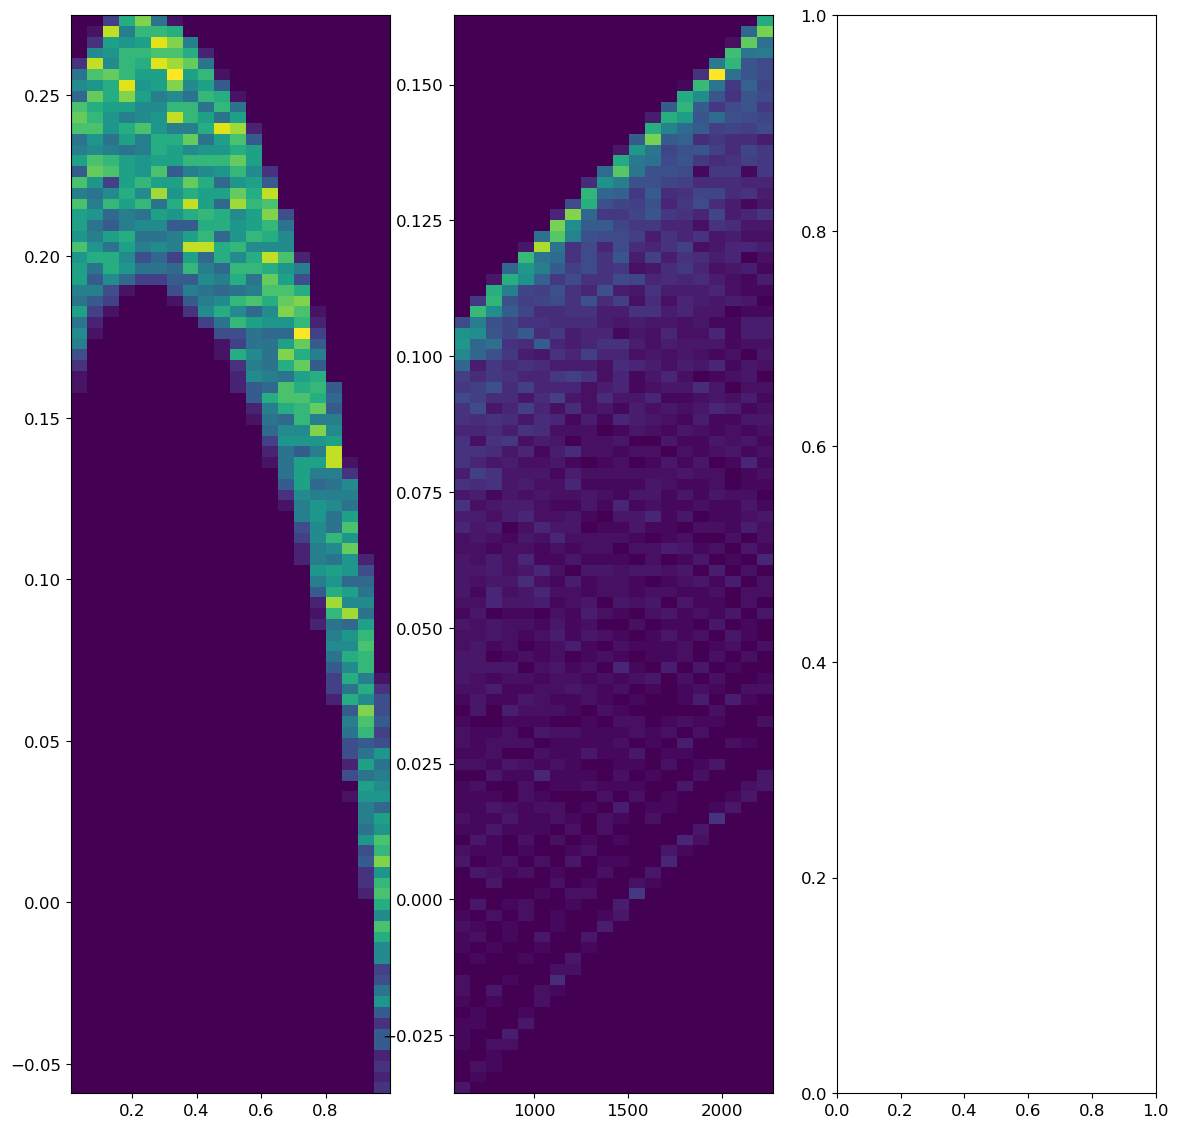

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(14,14))
for j in range(3):
  # for i in range(1):
    ax[j].hist2d(X_test[:,j], y_err2[:,j], bins=[20,100])

fig.suptitle("relative error")

# show plot
fig.tight_layout()
# plt.savefig('figures/' + filename_prefix + 'error_heat_map.png')
plt.show()